# PCA through Singular Value Decomposition

In [2]:
import numpy as np
# Defined 3 points in 2D-space:
X=np.array([[2, 1, 0],[4, 3, 0]])
# Calculate the covariance matrix:
# On calcule la matrice de corrélation (ou produit interne) pour la SVD
R = np.dot(X, X.T)

# Calculate the SVD decomposition and new basis vectors:
[U,D,V]=np.linalg.svd(R)  # call SVD decomposition
u1=U[:,0] # new basis vectors
u2=U[:,1]

# Calculate the coordinates in new orthonormal basis:
# Calcul des nouvelles coordonnées dans la base SVD
Xi = np.dot(U.T, X)

# Calculate the approximation of the original from new basis
#print(Xi1[:,None]) # add second dimention to array and test it
# Reconstruction de l'original à partir de la première composante uniquement
Xi1 = np.outer(U[:, 0], Xi[0, :])


# Check that you got the original
# Vérification du résultat final (reconstruction complète)
X_reconstructed = np.dot(U, Xi)
print("Données reconstruites :\n", X_reconstructed)


Données reconstruites :
 [[2. 1. 0.]
 [4. 3. 0.]]


# PCA on Iris data

In [3]:
# Load Iris dataset as in the last PC lab:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[:])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


<function matplotlib.pyplot.show(close=None, block=None)>

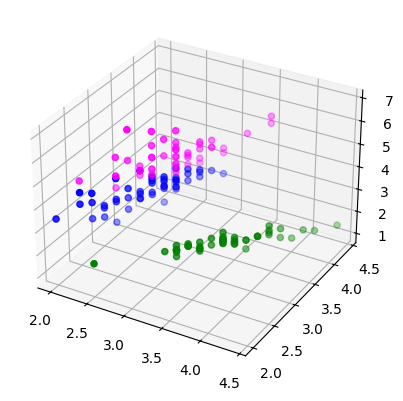

In [4]:
# We have 4 dimensions of data, plot the first three colums in 3D
X=iris.data
y=iris.target
import matplotlib.pyplot as plt
axes1=plt.axes(projection='3d')
axes1.scatter3D(X[y==0,1],X[y==0,1],X[y==0,2],color='green')
axes1.scatter3D(X[y==1,1],X[y==1,1],X[y==1,2],color='blue')
axes1.scatter3D(X[y==2,1],X[y==2,1],X[y==2,2],color='magenta')
plt.show


[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


<function matplotlib.pyplot.show(close=None, block=None)>

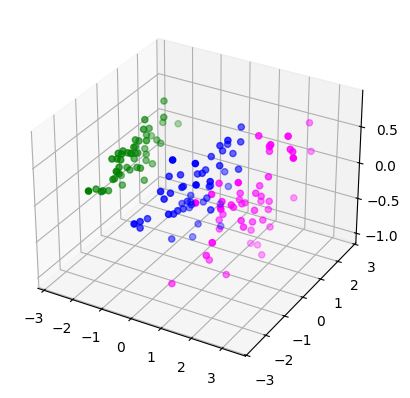

In [6]:
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn import decomposition
Xscaler = StandardScaler()
Xpp=Xscaler.fit_transform(X)

# define PCA object (three components), fit and transform the data
pca = decomposition.PCA(n_components=3)
pca.fit(Xpp)
Xpca = pca.transform(Xpp)
print(pca.get_covariance())
# you can plot the transformed feature space in 3D:
axes2=plt.axes(projection='3d')
axes2.scatter3D(Xpca[y==0,0],Xpca[y==0,1],Xpca[y==0,2],color='green')
axes2.scatter3D(Xpca[y==1,0],Xpca[y==1,1],Xpca[y==1,2],color='blue')
axes2.scatter3D(Xpca[y==2,0],Xpca[y==2,1],Xpca[y==2,2],color='magenta')
plt.show

In [7]:
# Compute pca.explained_variance_ and pca.explained_cariance_ratio_values
pca.explained_variance_

array([2.93808505, 0.9201649 , 0.14774182])

In [8]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762, 0.03668922])

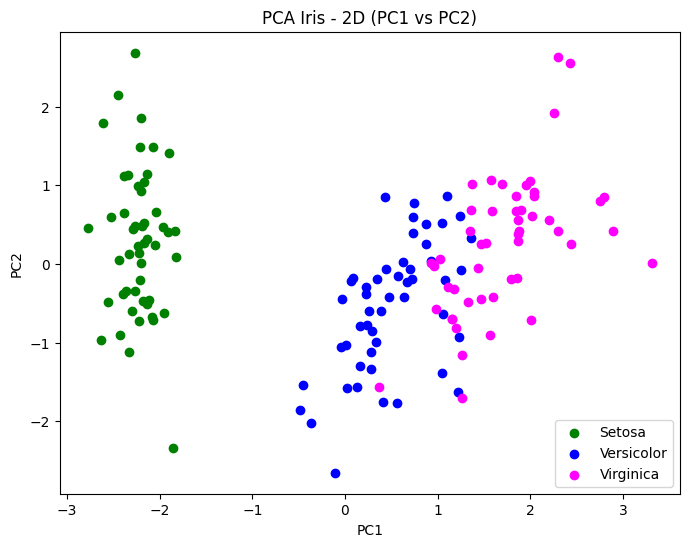

In [11]:
# Plot the principal components in 2D, mark different targets in color
# Affichage des deux premières composantes principales en 2D
plt.figure(figsize=(8,6))
plt.scatter(Xpca[y==0,0], Xpca[y==0,1], color='green', label='Setosa')
plt.scatter(Xpca[y==1,0], Xpca[y==1,1], color='blue', label='Versicolor')
plt.scatter(Xpca[y==2,0], Xpca[y==2,1], color='magenta', label='Virginica')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Iris - 2D (PC1 vs PC2)")
plt.legend()
plt.show()

# KNN classifier

Taille train/test : (105, 4) (45, 4)


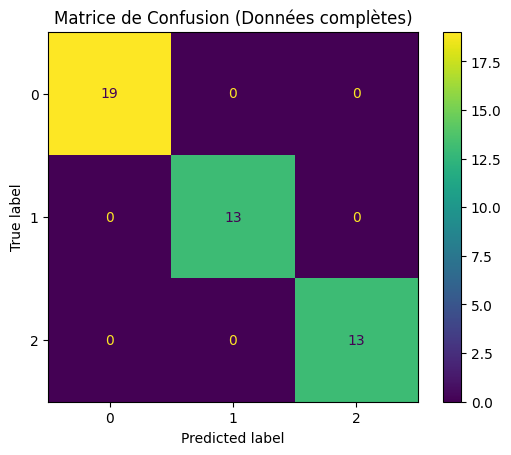

In [15]:
# Import train_test_split as in last PC lab, split X (original) into train and test, train KNN classifier on full 4-dimensional X

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Split X (original) into train and test:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Taille train/test :", X_train.shape, X_test.shape)

# Train KNN classifier on full 4-dimensional X:
knn1 = KNeighborsClassifier(n_neighbors = 3)
knn1.fit(X_train, y_train)
Ypred = knn1.predict(X_test)

# Show confusion matrix:
cm = confusion_matrix(y_test, Ypred)
ConfusionMatrixDisplay.from_predictions(y_test, Ypred)
plt.title("Matrice de Confusion (Données complètes)")
plt.show()



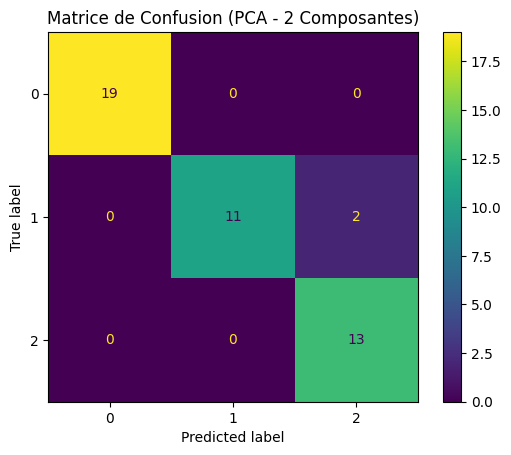

In [16]:
# Now do the same (data set split, KNN, confusion matrix), but for PCA-transformed data (1st two principal components, i.e., first two columns).
# Compare the results with full dataset
# PCA-transformed data (1st two principal components):
# Même processus avec les 2 premières composantes de la PCA
X_pca_2 = Xpca[:, :2]
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca_2, y, test_size=0.3, random_state=42)

knn_pca = KNeighborsClassifier(n_neighbors = 3)
knn_pca.fit(X_train_pca, y_train_pca)
Ypred_pca = knn_pca.predict(X_test_pca)

ConfusionMatrixDisplay.from_predictions(y_test_pca, Ypred_pca)
plt.title("Matrice de Confusion (PCA - 2 Composantes)")
plt.show()


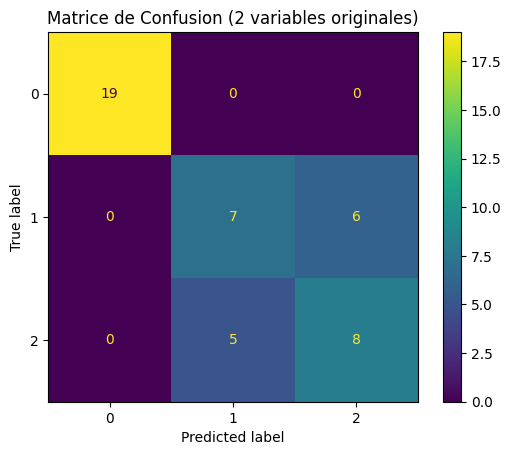

In [17]:
# Now do the same, but use only 2-dimensional data of original X (first two columns)
# Original X (first two columns only):
# Même processus avec les 2 premières variables originales (sans PCA)
X_orig_2 = X[:, :2]
X_train_orig2, X_test_orig2, y_train_orig2, y_test_orig2 = train_test_split(X_orig_2, y, test_size=0.3, random_state=42)

knn_orig2 = KNeighborsClassifier(n_neighbors = 3)
knn_orig2.fit(X_train_orig2, y_train_orig2)
Ypred_orig2 = knn_orig2.predict(X_test_orig2)

ConfusionMatrixDisplay.from_predictions(y_test_orig2, Ypred_orig2)
plt.title("Matrice de Confusion (2 variables originales)")
plt.show()
